# Ejemplo de regresión logistica binaria
### solo dos valores posibles de la v.a. y 
SE CONSIDERA:  La compora depende de si el visitante pasa más de 5 minutos y añade más de 2 productos.

In [10]:
import numpy as np
import pandas as pd
# Semilla para reproducibilidad
np.random.seed(42)
# Número de muestras
n_samples = 5000
# Generar tiempo en sitio (minutos) entre 1 y 10
tiempo = np.random.uniform(1, 10, n_samples)
# Generar cantidad de productos en carrito entre 0 y 5
productos = np.random.randint(0, 6, n_samples)
# Regla para determinar compra:
# Si tiempo > 5 y productos > 2 → compra = 1, si no → 0
compra = ((tiempo > 5) & (productos > 2)).astype(int)
# Crear DataFrame
data = pd.DataFrame({
'tiempo': tiempo,
'productos': productos,
'compra': compra
})
print(data.head())
print("\nTamaño del dataset:", data.shape)

     tiempo  productos  compra
0  4.370861          2       0
1  9.556429          2       0
2  7.587945          5       1
3  6.387926          3       1
4  2.404168          2       0

Tamaño del dataset: (5000, 3)


### 1. Preparación del entorno en Python
Este bloque prepara todas las herramientas necesarias para:
 - Cargar y manipular datos (pandas, numpy)
 - Entrenar un modelo de regresión logística (sklearn)
 - Evaluar el modelo (accuracy, matriz de confusión, reporte de clasificación)
 - Visualizar datos y resultados (matplotlib, seaborn)

In [11]:
# Librerías para crear el modelo de regresión logística
from sklearn import linear_model, model_selection
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sb
# Configuración para mostrar gráficos dentro del notebook
%matplotlib inline
# Comentario:


### 3. División Train/Test

In [12]:
# DIVISIÓN TRAIN/TEST
X = data[['tiempo', 'productos']] # Variables predictoras
y = data['compra'] # Variable objetivo
# División 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = model_selection.train_test_split(
X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((4000, 2), (1000, 2))

### 4. Entrenamiento del modelo de regresión logística

In [13]:
# ENTRENAMIENTO DEL MODELO
modelo = linear_model.LogisticRegression()
modelo.fit(X_train, y_train)
print("Coeficientes del modelo:", modelo.coef_)
print("Intercept:", modelo.intercept_)

Coeficientes del modelo: [[1.35440102 2.35022554]]
Intercept: [-16.86605224]


### 5. Evaluación completa del modelo

Predicciones

In [14]:
# Predicciones
y_pred = modelo.predict(X_test)
# Métricas
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

Accuracy: 0.909

Matriz de confusión:
 [[718  40]
 [ 51 191]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94       758
           1       0.83      0.79      0.81       242

    accuracy                           0.91      1000
   macro avg       0.88      0.87      0.87      1000
weighted avg       0.91      0.91      0.91      1000



Visualización de la frontera de decisión

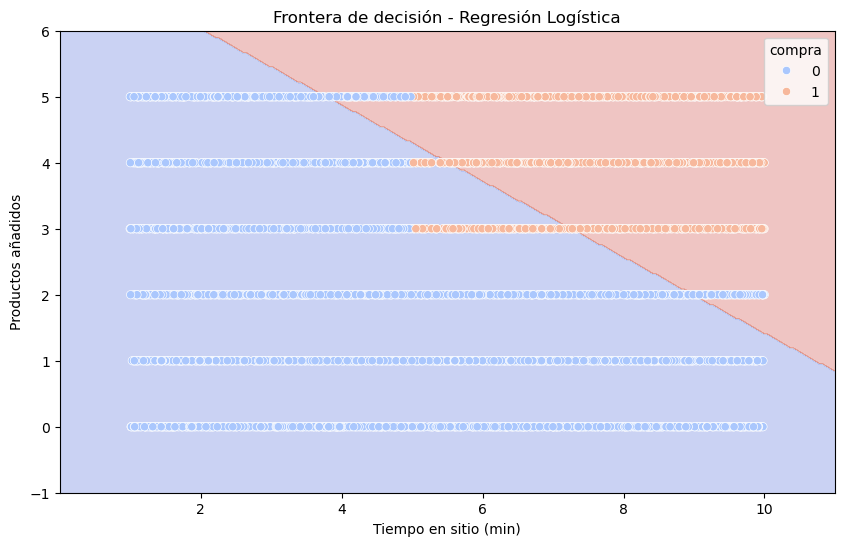

In [15]:
# VISUALIZACIÓN DE LA FRONTERA DE DECISIÓN
# Crear una malla de puntos
x_min, x_max = X['tiempo'].min() - 1, X['tiempo'].max() + 1
y_min, y_max = X['productos'].min() - 1, X['productos'].max() + 1
xx, yy = np.meshgrid(
np.linspace(x_min, x_max, 300),
np.linspace(y_min, y_max, 300)
)
# Crear DataFrame con nombres de columnas para evitar el warning
grid = pd.DataFrame({
'tiempo': xx.ravel(),
'productos': yy.ravel()
})
# Predicción sobre la malla
Z = modelo.predict(grid)
Z = Z.reshape(xx.shape)
# Gráfico
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
# Puntos reales
sb.scatterplot(data=data, x='tiempo', y='productos', hue='compra', palette='coolwarm')
plt.title("Frontera de decisión - Regresión Logística")
plt.xlabel("Tiempo en sitio (min)")
plt.ylabel("Productos añadidos")
plt.show()